# PV Energy Forecasting via Machine Learning

## Introduction

### Dataset Description

The dataset used in this project combines power production data from Sunnyside Solar Farm with weather data obtained from the Visual Crossing Weather API. The solar dataset contains timestamps and measured energy output from January 1, 2025 to February 9, 2026. Each entry represents a 15-minute power reading from the grid where exported solar power appears as negative values. Since the solar data is in 15-minute increments, the values will be summed into hourly energy totals to align with the weather dataset.

The weather dataset includes up to 42 environmental features. This includes solar radiation, temperature, cloud coverage, etc. All of which influence photovoltaic (PV) energy generation. Additionally, Visual Crossing provides weather forecasts up to 15 days ahead, allowing the model to potentially predict future power output based on forecasted conditions.

LPEA also indicated that some days contain inaccurate measurements or periods when the system was partially offline. Plotting the data will help identify these irregularities so that problematic periods can be evaluated and potentially excluded from the analysis.

### Problem Statement

>To what extent can an ML model predict PV energy output at Sunnyside Solar Farm whilst trained exclusively on publicly available forecast data?

### Project Goal

>To train an ML model that evaluates, ranks importance, and quantifies impacts of forecast variables on PV energy production.

## Data Loading & Exploration

In [1]:
# all libraries used
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from Models.ModelMaker import ModelMaker
from util.util import plot_forecasts

In [2]:
# Shows the full 24 hours in table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Load CSV file data 
weather_df = pd.read_csv('data/DRO_2025-01-01_2026-02-09.csv')

# Cleaning columns by removing spaces
weather_df.columns = weather_df.columns.str.strip()

# Identfy the column that contains the time information
possible_time_cols = ["datetime", "date", "time", "timestamp"]

for col in possible_time_cols:
    if col in weather_df.columns:
        time_col = col
        break
# Convert the time column to datatime format
weather_df[time_col] = pd.to_datetime(weather_df[time_col], errors="coerce")

# Removes bad timestamps and uses time column as the index
weather_df = (weather_df.dropna(subset=[time_col]).set_index(time_col).sort_index())

# Load forecast file and cleans data like weather
df_forecast = pd.read_json('data/forecast_example.json')
df_forecast.columns = df_forecast.columns.str.strip().str.lower()

# Compare the first 24 hours of each weather variable that exists in both datasets and creates table with HTML
for col in weather_df.columns:
    if col not in df_forecast.columns:
        continue

    hist = pd.to_numeric(weather_df[col].head(24), errors="coerce").reset_index(drop=True)
    forecast = pd.to_numeric(df_forecast[col].head(24), errors="coerce").reset_index(drop=True)
    time_labels = weather_df.index[:24].strftime("%m-%d %H:%M")
    comparison = pd.DataFrame([hist.round(2).values, forecast.round(2).values],index=["Historical", "Forecast"],columns=time_labels)
    
    print(f"\n{col}")

    html_table = f"""
    <div style="overflow-x:auto; width:100%; border:1px solid #ccc; padding:5px;">
        {comparison.to_html()}
    </div>
    """
    display(HTML(html_table))


temp


datetime,01-01 00:00,01-01 01:00,01-01 02:00,01-01 03:00,01-01 04:00,01-01 05:00,01-01 06:00,01-01 07:00,01-01 08:00,01-01 09:00,01-01 10:00,01-01 11:00,01-01 12:00,01-01 13:00,01-01 14:00,01-01 15:00,01-01 16:00,01-01 17:00,01-01 18:00,01-01 19:00,01-01 20:00,01-01 21:00,01-01 22:00,01-01 23:00
Historical,18.1,18.1,16.8,12.4,12.4,12.8,13.4,17.8,20.0,21.6,26.4,30.2,34.7,38.0,41.0,40.6,40.6,36.4,28.4,25.3,23.3,20.4,18.9,21.7
Forecast,23.6,25.4,26.8,25.2,20.9,24.7,23.3,21.5,25.6,35.5,43.1,47.0,51.0,53.0,54.9,56.0,54.9,54.1,47.9,45.0,42.0,40.9,38.9,38.0



feelslike


datetime,01-01 00:00,01-01 01:00,01-01 02:00,01-01 03:00,01-01 04:00,01-01 05:00,01-01 06:00,01-01 07:00,01-01 08:00,01-01 09:00,01-01 10:00,01-01 11:00,01-01 12:00,01-01 13:00,01-01 14:00,01-01 15:00,01-01 16:00,01-01 17:00,01-01 18:00,01-01 19:00,01-01 20:00,01-01 21:00,01-01 22:00,01-01 23:00
Historical,9.5,8.1,11.9,12.4,12.4,3.2,13.4,10.4,12.9,21.6,26.4,30.2,34.7,38.0,39.1,38.7,40.6,31.8,28.4,19.2,16.8,13.0,18.9,12.0
Forecast,17.6,18.6,21.2,25.2,12.1,20.2,18.8,21.5,20.9,35.5,39.5,44.2,51.0,53.0,54.9,56.0,54.9,54.1,45.3,42.6,40.2,39.0,38.9,38.0



dew


...

datetime,01-01 00:00,01-01 01:00,01-01 02:00,01-01 03:00,01-01 04:00,01-01 05:00,01-01 06:00,01-01 07:00,01-01 08:00,01-01 09:00,01-01 10:00,01-01 11:00,01-01 12:00,01-01 13:00,01-01 14:00,01-01 15:00,01-01 16:00,01-01 17:00,01-01 18:00,01-01 19:00,01-01 20:00,01-01 21:00,01-01 22:00,01-01 23:00
Historical,-75.3,-72.8,-63.3,-52.0,-40.1,-28.2,-16.6,-5.4,5.2,14.3,21.9,27.3,29.7,28.9,25.0,18.5,10.0,0.5,-10.7,-22.1,-33.9,-45.9,-57.6,-68.3
Forecast,-66.3,-65.8,-58.9,-48.8,-37.4,-25.5,-13.6,-2.0,9.3,19.5,28.2,34.8,38.2,38.0,34.0,27.1,18.2,7.9,-3.5,-15.2,-27.1,-38.9,-50.2,-59.9



stations


datetime,01-01 00:00,01-01 01:00,01-01 02:00,01-01 03:00,01-01 04:00,01-01 05:00,01-01 06:00,01-01 07:00,01-01 08:00,01-01 09:00,01-01 10:00,01-01 11:00,01-01 12:00,01-01 13:00,01-01 14:00,01-01 15:00,01-01 16:00,01-01 17:00,01-01 18:00,01-01 19:00,01-01 20:00,01-01 21:00,01-01 22:00,01-01 23:00
Historical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



source


datetime,01-01 00:00,01-01 01:00,01-01 02:00,01-01 03:00,01-01 04:00,01-01 05:00,01-01 06:00,01-01 07:00,01-01 08:00,01-01 09:00,01-01 10:00,01-01 11:00,01-01 12:00,01-01 13:00,01-01 14:00,01-01 15:00,01-01 16:00,01-01 17:00,01-01 18:00,01-01 19:00,01-01 20:00,01-01 21:00,01-01 22:00,01-01 23:00
Historical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After examination of features, cleaning the dataset is strictly necessary. Features such as:

- "source" and "stations" do not provide meaningful information and are thus dropped.
- "sealevelpressure" is removed because it does not relate to the forecast dataset.
- "preciptype", which contains categorical or missing values, so it must either be encoded numerically or excluded from the dataset.

### Daily & Weekly Power Plots

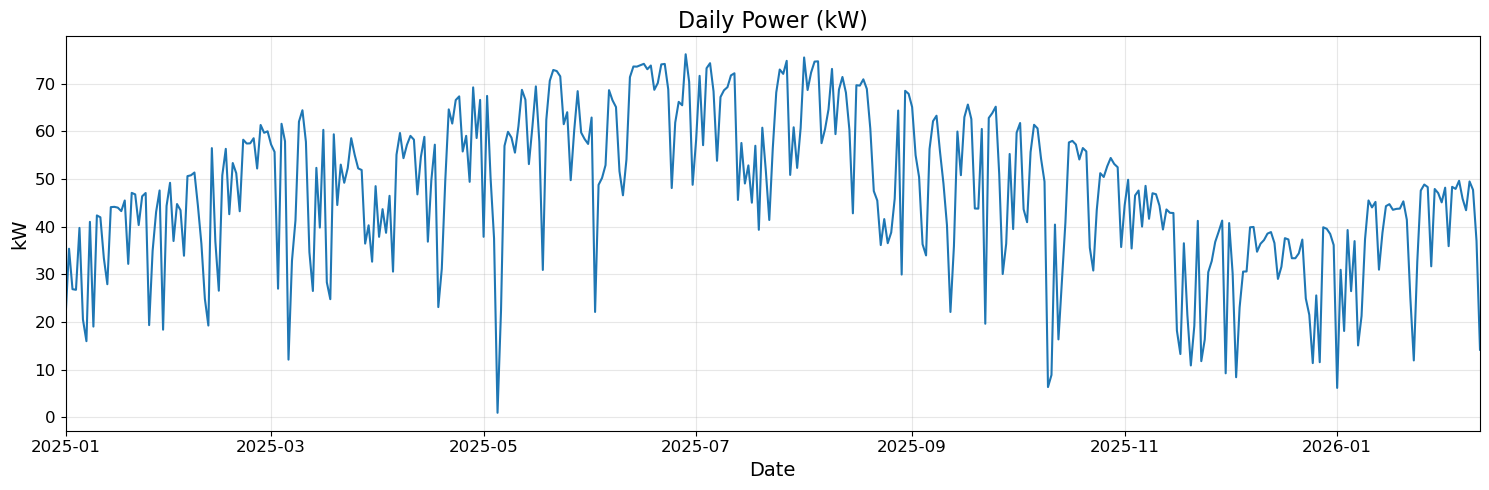

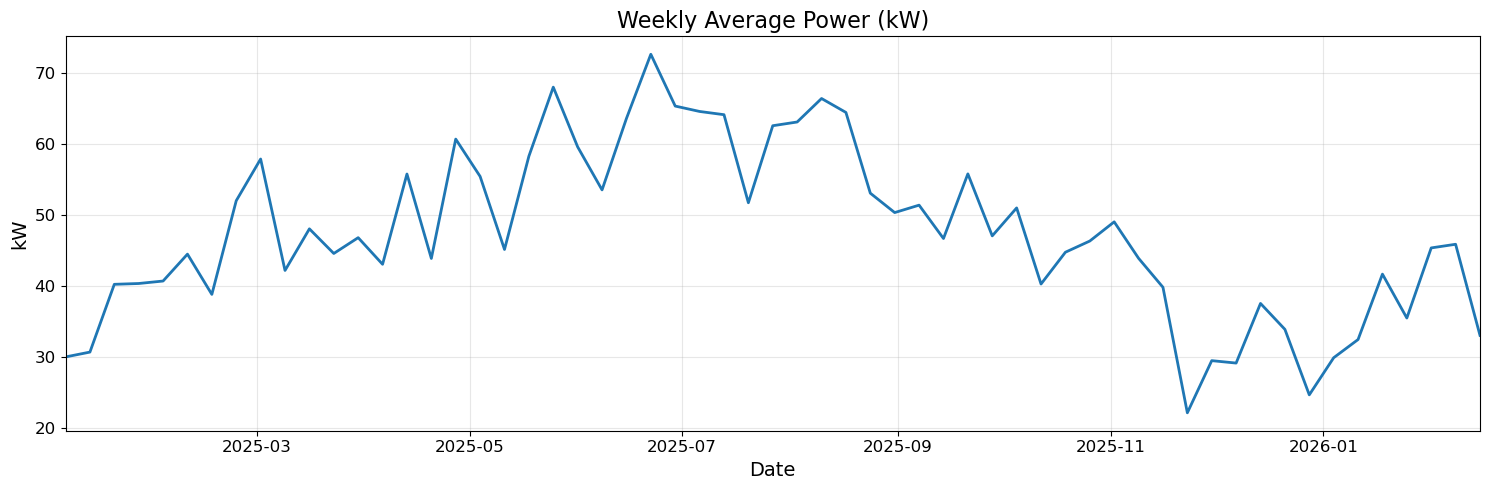

In [3]:
# "power" readings from Sunnyside Solar Farm
p_data = pd.read_csv("data/SunnysideTotalPower2025-01-01_2026-02-12.csv")

# organize data
p_data["timestamp"] = pd.to_datetime(p_data["timestamp"])
p_data = p_data.set_index("timestamp")
p_data["power"] = -p_data["power"]   # since data is measured as power reduced from grid

# resample data
hourly = p_data.resample('h').mean()   # convert from W to kWh
daily = p_data.resample('D').sum()
weekly = daily.resample('W').mean()

### Plotting ###
# Daily Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily.index, daily["power"] / 1000, linewidth=1.5)

ax.set_xlim(daily.index.min(), daily.index.max())
ax.set_title("Daily Power (kW)", fontsize=16)
ax.set_ylabel("kW", fontsize=14)
ax.set_xlabel("Date", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(True, alpha=0.3)
plt.tight_layout()

# Weekly Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(weekly.index, weekly["power"] / 1000, linewidth=2)

ax.set_xlim(weekly.index.min(), weekly.index.max())
ax.set_title("Weekly Average Power (kW)", fontsize=16)
ax.set_ylabel("kW", fontsize=14)
ax.set_xlabel("Date", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The daily power plot revealed short term variability from weather, snow cover, or system issues. The weekly plot smooths out the fluctuations from the daily plot, and visualizes larger trends depending on the weather.

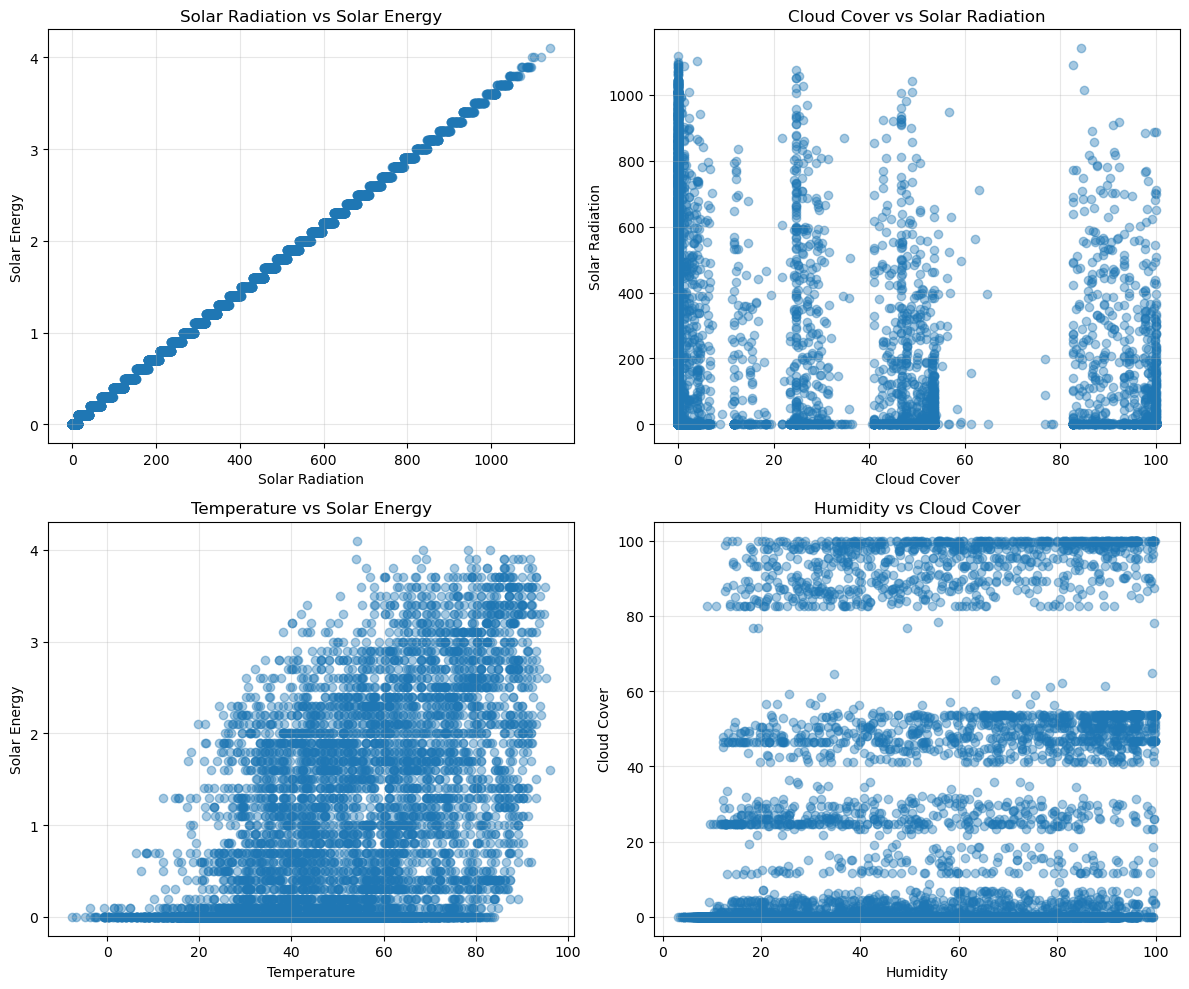

In [4]:
# Select a few important numeric features
features = ["solarradiation", "solarenergy", "cloudcover", "temp", "humidity"]

df_features = weather_df[features].dropna()

# Create scatter plots comparing features
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].scatter(df_features["solarradiation"], df_features["solarenergy"], alpha=0.4)
axes[0,0].set_title("Solar Radiation vs Solar Energy")
axes[0,0].set_xlabel("Solar Radiation")
axes[0,0].set_ylabel("Solar Energy")

axes[0,1].scatter(df_features["cloudcover"], df_features["solarradiation"], alpha=0.4)
axes[0,1].set_title("Cloud Cover vs Solar Radiation")
axes[0,1].set_xlabel("Cloud Cover")
axes[0,1].set_ylabel("Solar Radiation")

axes[1,0].scatter(df_features["temp"], df_features["solarenergy"], alpha=0.4)
axes[1,0].set_title("Temperature vs Solar Energy")
axes[1,0].set_xlabel("Temperature")
axes[1,0].set_ylabel("Solar Energy")

axes[1,1].scatter(df_features["humidity"], df_features["cloudcover"], alpha=0.4)
axes[1,1].set_title("Humidity vs Cloud Cover")
axes[1,1].set_xlabel("Humidity")
axes[1,1].set_ylabel("Cloud Cover")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The above scatter plots show several important relationships between weather variables and solar energy production:
- Solar radiation had a strong positive linear correlation with energy.
- Cloud cover shows a negative relationship with radiation as higher cloud coverage blocks the sunlight and reduces incoming radiation.
- Temperature also shows a positive trend with energy, likely because warmer conditions are linked to clear skies and stronger sunlight.
- Humidity tends to increase with cloud cover, reflecting atmospheric conditions that form cloud formation.

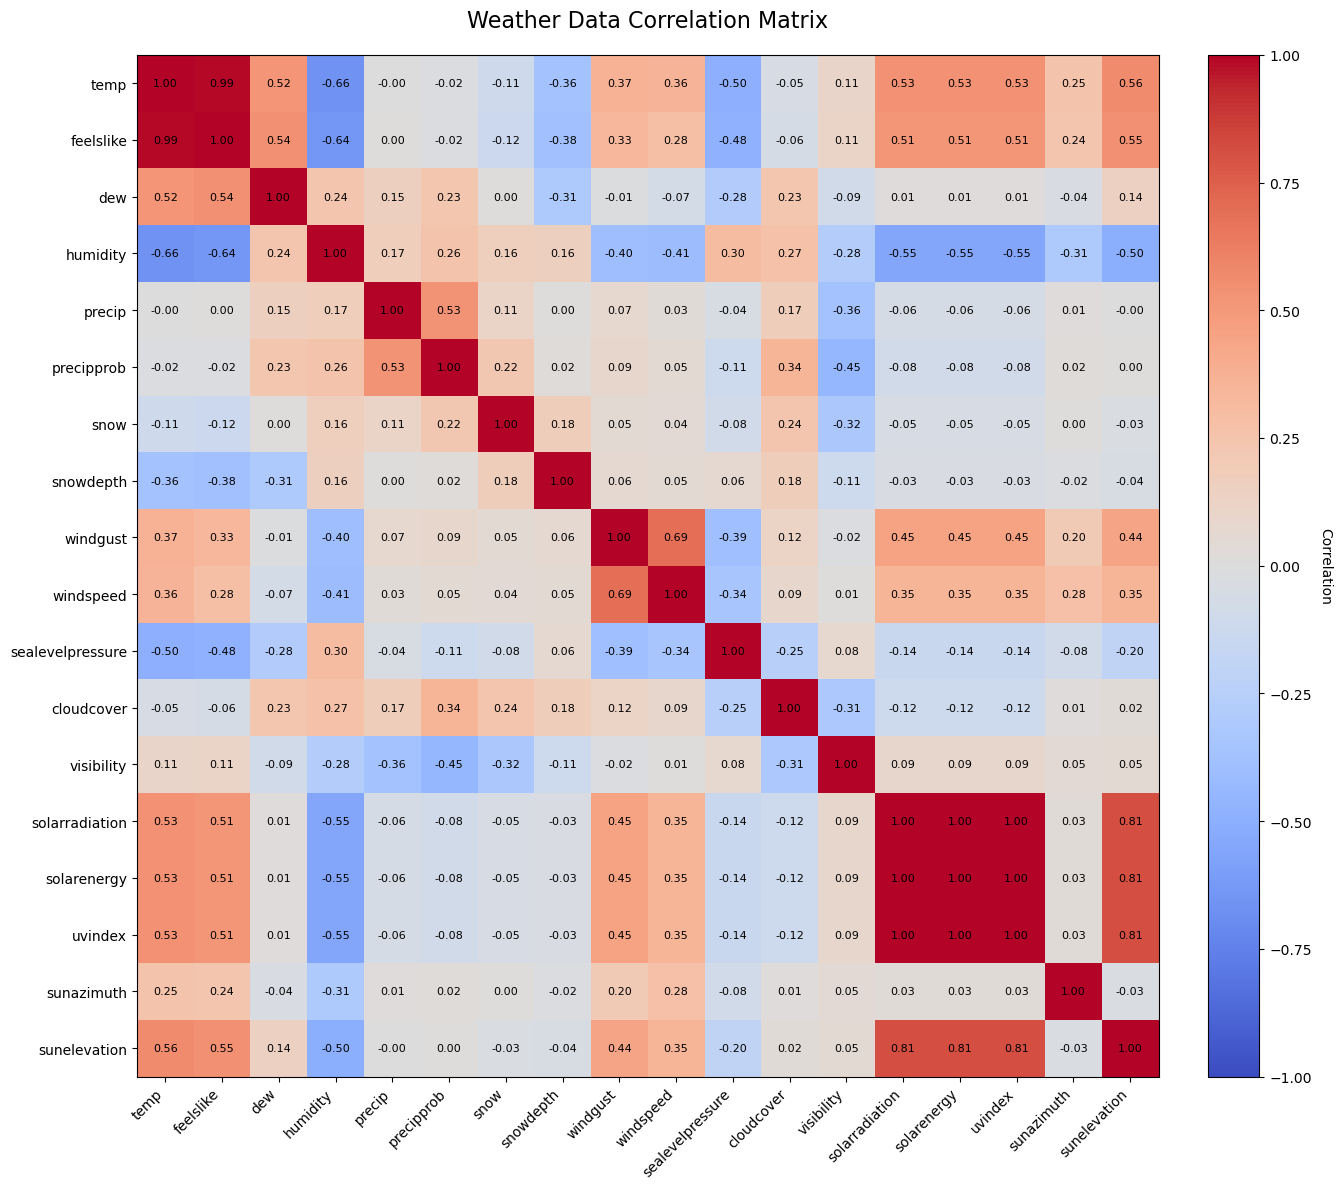

In [5]:
# Drop features that are not useful for correlation analysis.
exclude_cols = ['name', 'preciptype', 'winddir', 'source', 'stations']
df_filtered = weather_df.drop(columns=[col for col in exclude_cols if col in weather_df.columns])

# Keep only numeric columns so correlation can be calculated.
df_numeric = df_filtered.select_dtypes(include='number')

# Calculate the correlation matrix.
corr = df_numeric.corr()

# Create the plot.
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar to show correlation strength.
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation", rotation=270, labelpad=15)

# Set tick marks and labels.
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Add correlation values inside each square.
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black')

# Add title.
ax.set_title("Weather Data Correlation Matrix", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

Based on the correlation matrix and understanding of forecast data, the _UV index_ feature must be avoided since it is **highly** correlated to solar radiation and solar energy. (but it forecasting UV index - not sure what is meant here) This makes forecasting more difficult for our models.

The _feels-like_ feature can also be ignored since it is correlated to temperature.

## Data Preparation 

Some preprocessing was required to ensure the dataset did not contain any missing values or invalid points that might affect our models. Since the original dataset contained 15-minute increments power measurements, it was resampled into hourly averages but in order to match with the Visual Crossing data.

For feature engineering, additional variables were created to represent the physical behavior of the solar panels. PV cell temperature estimates were calculated using ambient temperatures and solar radiation, which approximated the panels operating temperature.

Since panel efficiency decreases as temp increases, it captures the temperature effects of the power output.
$$
T_{cell} = (T_{air}-32)\frac{5}{9} + \left(\frac{41-20}{800}\right)G
$$
Optimal performance was found at 41 degrees, with 20 degrees acting as a baseline of ambient conditions. The difference is then divided by 800 (based on the magnitude of solar radiation).

Heat loss was another feature added. It also represents the thermal difference between the panels and the surrounding air, which can influence the panel efficiency. **TODO FIX THIS DESCRIPTION TO MATCH EQUATION**
$$
HeatLoss = T_{air} \times SolarRadiation
$$

The dataset was then split into training and testing sets using 80/20 split, allowing the model to be trained on the majority of the data while having unseen data for performance evaluation. 


# Models

All models were trained using a custom grid search and cross-validated with a 5-fold CV. However, the RidgeCV and LSTMRegression models were excluded from the 5-fold CV due to these factors respectively: a more efficient cross-validation method, and being **significantly** limited in computational power (Tried to interpret what you meant Tyler). These models are only examples of the most outstanding models (both good and bad) that were trained and tested. In doing so, the total number of models trained exceeded 20,000 and my GPU's energy consumption was greater than 2,000 Watts.


In [2]:
from Models import ModelMaker


# create a model maker to demonstrate all the models cleanly
mm = ModelMaker()

# Note: if you are running the cells below on CPU (see `Available Processors` below), it may take a significant amount of time!

ModuleNotFoundError: No module named 'tensorflow'

### Features

The code below contains the list of features that will be demonstrated in the models. Again, nearly all features were tested in the exploration of each model, but these features are the ones that stood out.

In [ ]:
features = [
    ["temp", "cloudcover", "dtemp", "dsolarradiation", "windspeed", "hcos", "hsin", "celltemp"],
    ["cloudcover", "solarradiation", "dtemp", "dsolarradiation", "windspeed", "hcos"],
    ["temp", "cloudcover", "solarradiation", "dtemp", "dsolarradiation", "solarenergy", "hcos", "hsin", "celltemp"],
    ["cloudcover", "dcloudcover", "hsin"],
    ["temp", "cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "windspeed", "hcos", "hsin", "celltemp"],
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "celltemp"],
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "celltemp", "temp"],
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "heatloss", "temp"],
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "heatloss"],
    ["temp", "solarradiation", "dcloudcover", "dsolarradiation", "hcos"],
    ["cloudcover", "dtemp", "dsolarradiation", "windspeed", "hcos", "hsin"],
    ["temp", "solarradiation", "sunelevation", "cloudcover", "sunazimuth", "solarenergy"],
]

# commonly preferred by neural nets
features_small = [
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "celltemp"],
    ["cloudcover", "solarradiation", "dcloudcover", "dtemp", "dsolarradiation", "solarenergy", "hcos", "celltemp", "temp"],
]

rs = 42   # random state

## Ridge Regression

20,000 feature combinations were ran for RidgeRegression model. The list ridge_features represents the preferred feature metrics for the ridge regression model after feature combinations were tested.

In [ ]:
ridge_params = {
    "tts": [0.2],
    "alphas": [np.logspace(-3, 3, 100)],
}
ridge_features = ["temp", "cloudcover", "dtemp", "dsolarradiation", "windspeed", "hcos", "hsin", "celltemp"]

mm.train_and_eval("RidgeRegression", [ridge_features], ridge_params, rs)

# save best model for comparison
ridge = mm.choose_best(0)
ridge_features = ["temp", "cloudcover", "dtemp", "dsolarradiation", "windspeed", "hcos", "hsin", "celltemp"]

## MLP Regression



In [ ]:
mlp_params = {
    "tts": [0.2],
    "activation": ["relu"],
    "learning_rate_init": [0.001, 0.005],
    "hidden_layer_sizes": [(64, 32), (256, 128, 64, 32)],
    "alpha": [0.001, 0.01, 0.1],
    "max_iter": [800],
    "early_stopping": [True],
    "batch_size": [32, 64],
}

mm.train_and_eval("MLPRegression", features_small, mlp_params, rs)

## Random Forest 

In [ ]:
rf_params = {
    "tts": [0.2],
    "n_estimators": [100, 300, 600],
    "max_depth": [15, 20],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
    "bootstrap": [True]
}
rf_features = features_small.copy()
rf_features.append(features[-1])
print(rf_features)   # TODO REMOVE THIS!

mm.train_and_eval("RandomForestRegressor", rf_features, rf_params, rs)

## Gradient Boosting 

In [ ]:
# TODO!!!!!!!!!!!!!!!!

## LSTM Regression

Long Short-Term Memory (LSTM) Regression is a type of recurrent neural network that has the unique capability to predict value sequentially. Since weather and solar energy production are time series data, the model is well-suited for the data. The model performed exceptionally well on the ramp up and ramp down phases of the daily energy curve, but oddly, the model did struggle to capture the peak of the day accurately.

While testing, some models were quite confident in their impossibly high mid-day power values. This is the exact reason that led to the creation of the cell-temp parameter. Models with higher _lookback_ (beyond 48hrs) also contributed to impossible mid-day power values. Also, since LSTM Regression depends on sequential data, there is a good chance that some of the model's testing data was a sequence of difficult days to predict, or in other words, the testing data was clumped together which made interpreting model performance difficult. A **much** larger dataset could elimiate this problem.

In [ ]:
# WARNING TO USER:
#                   THIS CELL CAN TAKE A LONG TIME TO RUN ON CPU!

lstm_params = {
    "tts": [0.2],
    "lookback": [48],
    "epochs": [500],
    "batch_size": [32],
    "lstm_units_1": [128, 64],
    "lstm_units_2": [64, 32],
    "lstm_units_3": [32, 16],
    "dense_units": [16],
    "dropout_rate": [0.3],
    "validation_split": [0.1]
}

mm.train_and_eval("LSTMRegressor", [features_small[1]], lstm_params, rs)

## Model Comparsion 

In [ ]:
from Data.ModelData.ModelData import ModelData
from util.util import plot_forecasts, clamp_predictions

NUM_DAYS_FORCAST = 1

with open("data/forecast_example.json", 'r') as f:
    forcast_data = json.load(f)


df = pd.read_csv("data/147_2026-02-10-2026-02-10_Sunnyside Export for FLC.csv", skiprows=[0, 1, 2, 3, 5])

# Convert Timestamp  datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

hourly_kwh = df['Production meter active power'].resample('h').mean()
actual_energy = hourly_kwh.values[:24].tolist()

# create data frame from API data
forcast_data = pd.DataFrame(forcast_data)
forcast_data["datetime"] = pd.to_datetime(forcast_data["date"] + " " + forcast_data["time"])

model_data = ModelData(forcast_data)
prediction_data1 = model_data.features.copy(True)[ridge_features]

# predict using forecast data
ridge_res = ridge.predict(prediction_data1)[:24]

### slice data into days ###
# weather
model_data.features = model_data.features[:24]
features_days = [model_data.features[i:i+24] for i in range(0, len(model_data.features), 24)]

# predictions
ridge_days = [ridge_res[i:i+24] for i in range(0, len(ridge_res), 24)]

# clamp
ridge_clamped = clamp_predictions(ridge_days[0], features_days[0].index, model_data.weather["sunelevation"])

print(ridge_clamped)
print(prediction_data1)

plot_forecasts({"ridge": ridge_clamped}, date_str="2026-02-10")

# TODO note sure what teh FUCK is going on here, but ill try to figure it out before its due

added comparsion all models, on a scatter plot, models and true values. 

## Feature Importance & Interpretation

## Final Recommendations

### Best model

### Limitations and uncertainties

### Practical deployment considerations

### Future work

## Conclusion 